# **Imports**

In [27]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

# **Load Data**

## DNFData.mat

In [28]:
DNF_Data = loadmat('DNFData.mat')
DNF_Data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Sat Oct 17 14:16:00 2015',
 '__version__': '1.0',
 '__globals__': [],
 'Data': array([[1, 1, 0, ..., 1, 1, 0],
        [1, 1, 0, ..., 1, 1, 0],
        [1, 1, 0, ..., 0, 1, 0],
        ...,
        [0, 1, 0, ..., 1, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 1, 0]], shape=(2000, 101), dtype=uint8)}

In [29]:
DNF_Data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Data'])

In [30]:
data = DNF_Data['Data']
data

array([[1, 1, 0, ..., 1, 1, 0],
       [1, 1, 0, ..., 1, 1, 0],
       [1, 1, 0, ..., 0, 1, 0],
       ...,
       [0, 1, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 1, 0]], shape=(2000, 101), dtype=uint8)

In [31]:
x = data[:, :-1]
y = data[:, -1]

In [32]:
x

array([[1, 1, 0, ..., 0, 1, 1],
       [1, 1, 0, ..., 1, 1, 1],
       [1, 1, 0, ..., 1, 0, 1],
       ...,
       [0, 1, 0, ..., 0, 1, 0],
       [1, 0, 0, ..., 1, 0, 0],
       [1, 1, 1, ..., 1, 0, 1]], shape=(2000, 100), dtype=uint8)

In [33]:
y

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,), dtype=uint8)

## DNFNoisy.mat

In [34]:
DNF_Noisy = loadmat('DNFNoisy.mat')
DNF_Noisy

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Sat Oct 17 14:17:00 2015',
 '__version__': '1.0',
 '__globals__': [],
 'Data_Noisy': array([[1, 1, 1, ..., 0, 0, 0],
        [0, 1, 0, ..., 1, 0, 1],
        [0, 1, 1, ..., 1, 0, 1],
        ...,
        [1, 1, 1, ..., 1, 0, 1],
        [0, 0, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 0, 0, 0]], shape=(500, 51), dtype=uint8)}

In [35]:
DNF_Noisy.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Data_Noisy'])

In [36]:
Data_Noisy = DNF_Noisy['Data_Noisy']
Data_Noisy

array([[1, 1, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 1, 0, 1],
       [0, 1, 1, ..., 1, 0, 1],
       ...,
       [1, 1, 1, ..., 1, 0, 1],
       [0, 0, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 0, 0, 0]], shape=(500, 51), dtype=uint8)

In [37]:
x_noisy = Data_Noisy[:, :-1]
y_noisy = Data_Noisy[:, -1]

In [38]:
x_noisy

array([[1, 1, 1, ..., 1, 0, 0],
       [0, 1, 0, ..., 0, 1, 0],
       [0, 1, 1, ..., 1, 1, 0],
       ...,
       [1, 1, 1, ..., 0, 1, 0],
       [0, 0, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 0, 0]], shape=(500, 50), dtype=uint8)

In [39]:
y_noisy.shape

(500,)

# **Task One: DNF Learning**

## 1. Learn Single Rule (Conjunction) 


In [40]:
def learn_single_rule(P_indices, X, y):
    """
    Starts with an empty rule (True) and iteratively adds features
    until all negative examples are ruled out.
    """
    
    num_features = X.shape[1]
    r_features = np.zeros(num_features, dtype=bool)

    N_idx = np.where(y == 0)[0]
    current_N = list(N_idx)    # Negative examples not yet ruled out by r

    while len(current_N) > 0:
        if np.all(r_features):
            return None
        
        best_f = None
        best_score = -np.inf # Heuristic value
        
        for f in range(num_features):
            if r_features[f]:
                continue # Skip features already added
            
            # Try adding feature f
            temp_r = r_features.copy()
            temp_r[f] = True
            
            # n_j+: positive examples covered by r ∧ f
            n_pos = np.sum(np.all(X[P_indices][:, temp_r] == 1, axis=1))
            
          # n_j-: negative examples still not ruled out, covered by r ∧ f
            n_neg = np.sum(np.all(X[current_N][:, temp_r] == 1, axis=1))
            
            score = n_pos / max(n_neg, 0.001)            # Heuristic
            
            if score > best_score:
                best_score = score
                best_f = f
        
        if best_f is None:
            return None
        
        # Add best feature
        r_features[best_f] = True
        
        # Update current_N: only negatives still covered by updated rule
        current_N = [idx for idx in current_N if X[idx, best_f] == 1]
    
    return r_features


## 2. Learn a Full DNF (Disjunction of Conjunctions)

In [41]:
def learn_DNF(X_train, y_train):
    """
    Learns a DNF formula by repeatedly:
        - Learning a single conjunction rule 'r' to cover positive examples.
        - Removing positive examples covered by 'r'.
        - Adding 'r' to the hypothesis (DNF).
        
    """
    P = list(np.where(y_train == 1)[0])   # Indices of positive examples currently NOT covered
    N_all = list(np.where(y_train == 0)[0])  # Indices of ALL negative examples in the training set
    
    hypo_rules = [] # The learned DNF hypothesis (a list of conjunction rules)
    
    while len(P) > 0: # Loop until all positive examples are covered
        # Learn one conjunction rule 'r' that covers some positives and rules out all negatives
        r = learn_single_rule(P,  X_train , y_train ) 
        
        if r is None:
            return None # Fail to learn a rule
        
        hypo_rules.append(r) # Add the learned rule to the DNF hypothesis
        
        # Identify positive examples (from current P) that are covered by the new rule 'r'
        covered_in_P = [idx for idx in P if np.all(X_train[idx, r] == 1)]
        
        if len(covered_in_P) == 0:
            return None # Contradiction: The learned rule 'r' doesn't cover any of the remaining positives
        
        # Remove covered positives from the set of remaining positives
        P = [idx for idx in P if idx not in covered_in_P]
        
    return hypo_rules

## 3. Predict using the Learned DNF

In [42]:
def predict_DNF(X, rules):
    """
    Evaluates the DNF formula (a disjunction over all conjunction rules).

    Returns:
        np.array (int): Predicted labels (0 or 1).
    """
    if rules is None:
        return np.zeros(len(X), dtype=int) # If no DNF rules, predict all 0s
    
    final_preds = np.zeros(len(X), dtype=bool) # Initialize predictions to False
    
    # DNF = r1 OR r2 OR ... (Each 'r' is a conjunction (AND))
    for r in rules:
        # A conjunction rule 'r' is True for an example if all features in 'r' are 1
        condition = np.all(X[:, r] == 1, axis=1)
        # Combine with previous predictions using logical OR
        final_preds = np.logical_or(final_preds, condition)
        
    return final_preds.astype(int)

## 4. Turn the DNF model into a readable string

In [43]:
def format_DNF(dnf_model):
    """
    Turn the DNF model into a readable string like:
    (x1 ∧ x7) ∨ (x3)
    """
    if not dnf_model:
        return "False"

    clauses = []

    for r in dnf_model:
        feats = [f"x{j+1}" for j in np.where(r)[0]]

        # Skip empty conjunctions
        if len(feats) == 0:
            continue

        clauses.append("(" + " ∧ ".join(feats) + ")")

    return " ∨ ".join(clauses) if clauses else "False"

## 5. Main Experiment: Train Evaluation loop

In [44]:
# Assumption: The dataset is noiseless, i.e., labels are fully consistent with some DNF.

train_sizes = np.arange(20, 1001, 20)
errors = []
zero_error_size = None      # To store the training size when error first becomes zero
final_dnf_model = None      # To store the DNF rules at that point

for t in train_sizes:
    # Split data into training and validation sets
    X_train, y_train = x[:t], y[:t]
    X_val, y_val = x[t:], y[t:]
    
    # Learn the DNF model on the training data
    rules = learn_DNF(X_train, y_train)
    
    if rules is None:
        errors.append(1.0)
    else:
        # Make predictions on the validation set
        y_pred = predict_DNF(X_val, rules)
        # Calculate the error rate
        err = np.mean(y_pred != y_val)
        errors.append(err)
        
        # Record the training size and model when validation error first reaches zero
        if err == 0 and zero_error_size is None:
            zero_error_size = t
            final_dnf_model = rules

## 6. Plot Learning Curve

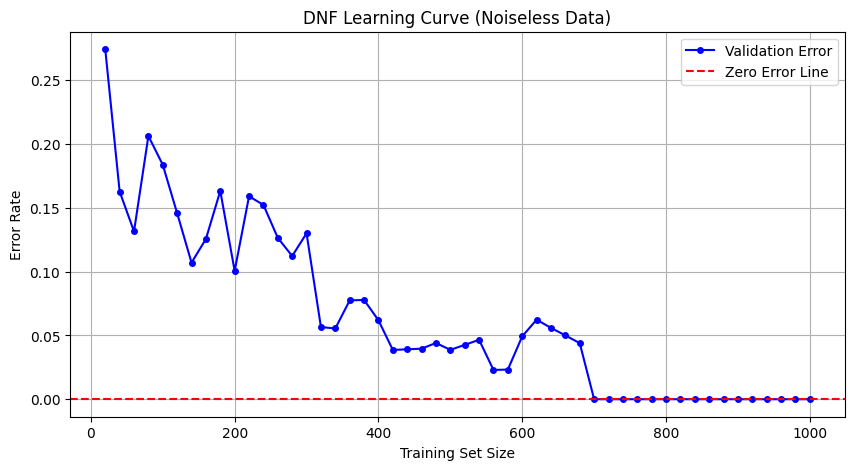

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(train_sizes, errors, 'b-o', markersize=4, label='Validation Error')
plt.axhline(0, color='r', linestyle='--', label='Zero Error Line')
plt.xlabel('Training Set Size')
plt.ylabel('Error Rate')
plt.title('DNF Learning Curve (Noiseless Data)')
plt.grid(True)
plt.legend()
plt.savefig("plots/DNF Learning Curve.jpg")
plt.show()

## 7. Display Results

In [46]:
if zero_error_size:

    print(
        f"\nValidation error first reached ZERO "
        f"at training size = {zero_error_size}"
    )

    print("\nExtracted DNF Formula:\n")

    print("Final DNF:")
    print(format_DNF(final_dnf_model))

else:

    print(
        "\nValidation error never reached zero "
        "within training sizes 20–1000."
    )


Validation error first reached ZERO at training size = 700

Extracted DNF Formula:

Final DNF:
(x1 ∧ x2 ∧ x3 ∧ x4 ∧ x5) ∨ (x95 ∧ x96 ∧ x97 ∧ x98 ∧ x99 ∧ x100)


# **Task Two: Noisy DNF Learning**

## 1. Learn Single Rule (Conjunction) 

In [47]:
def learn_single_rule_noisy(X, y, P_idx, epsilon):
    """
    Learn one conjunctive rule  in the noisy setting.
    Stops when remaining negatives are <= nn = epsilon * |N_initial|
    or when the algorithm cannot make progress.
    """
    n_features = X.shape[1]
    r_features = np.zeros(n_features, dtype=bool)

    # Initial negative set 
    N_idx = np.where(y == 0)[0]
    nn = epsilon * len(N_idx)

    # Repeat until N has fewer than nn elements or not progressing
    while len(N_idx) > nn:
        best_f = None
        best_score = -np.inf
        made_progress = False

        for f in range(n_features):
            if r_features[f]:
                continue

            temp = r_features.copy()
            temp[f] = True

            # n_j^+ : positives (still uncovered) that satisfy current rule + candidate feature
            n_pos = np.sum(np.all(X[P_idx][:, temp] == 1, axis=1))

            # n_j^- : negatives (still remaining) that satisfy candidate feature (given current stage)
            n_neg = np.sum(np.all(X[N_idx][:, temp] == 1, axis=1))

            score = n_pos / max(n_neg, 0.001)  # heuristic v_j

            if score > best_score:
                best_score = score
                best_f = f
                made_progress = True

        # Handle failure to progress
        if (not made_progress) or (best_f is None):
            break

        # Add best feature to rule
        r_features[best_f] = True

        N_idx = N_idx[X[N_idx][:, best_f] == 1]

    return r_features

## 2. Learn a Full DNF (Disjunction of Conjunctions)

In [48]:
def learn_DNF_noisy(X, y, epsilon):
    """
    Sequential covering to learn a DNF (disjunction of conjunctions) in the noisy setting.
    Stops when remaining positives are <= np = epsilon * |P_initial|
    or when no progress is possible.
    """
    P_idx = np.where(y == 1)[0]
    np_thresh = epsilon * len(P_idx)

    dnf_model = []  # list of clauses; each clause is a boolean mask of selected features

    # Loop until P has fewer than np elements or not progressing
    while len(P_idx) > np_thresh:
        r = learn_single_rule_noisy(X, y, P_idx, epsilon)

        # Handle failure to progress (empty clause)
        if not np.any(r):
            break

        dnf_model.append(r)

        covered = np.all(X[P_idx][:, r] == 1, axis=1)
        P_idx = P_idx[~covered]

    return dnf_model

## 3. Predict using the Learned DNF

In [ ]:
def predict_DNF(dnf_model, X):
    """
    Predict with a DNF model (list of clauses).
    
    """
    y_pred = np.zeros(X.shape[0], dtype=int)
    for r in dnf_model:
        satisfied = np.all(X[:, r] == 1, axis=1) if np.any(r) else np.zeros(X.shape[0], dtype=bool)
        y_pred[satisfied] = 1
    return y_pred

## 4. Turn the DNF model into a readable string

In [50]:
def format_DNF(dnf_model):
   
    if not dnf_model:
        return "False"
    clauses = []
    for r in dnf_model:
        feats = [f"x{j+1}" for j in np.where(r)[0]]
        if len(feats) == 0:
            continue
        clauses.append("(" + " ∧ ".join(feats) + ")")
    return " ∨ ".join(clauses) if clauses else "False"

## 5. Main Experiment: Epsilon sweep

In [51]:
# Experiment: epsilon sweep 
# Split: train length = 250, validation = remaining 250
X_train, y_train = x_noisy[:250], y_noisy[:250]
X_val,   y_val   = x_noisy[250:], y_noisy[250:]

epsilons = np.arange(0.001, 1.001, 0.05)

val_errors = []
best_eps = None
best_err = np.inf
best_dnf = None

for eps in epsilons:
    dnf = learn_DNF_noisy(X_train, y_train, eps)
    y_pred = predict_DNF(dnf, X_val)
    err = np.mean(y_pred != y_val)

    val_errors.append(err)

    if err < best_err:
        best_err = err
        best_eps = eps
        best_dnf = dnf

## 6. Plot Error vs Epsilon curve

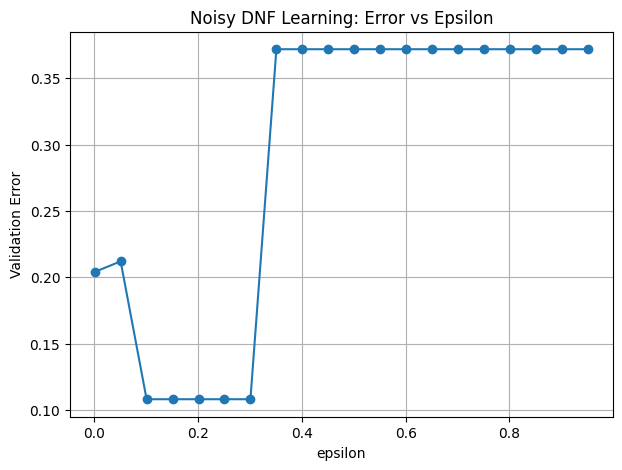

In [52]:
plt.figure(figsize=(7, 5))
plt.plot(epsilons, val_errors, marker="o", linewidth=1.5)
plt.xlabel("epsilon")
plt.ylabel("Validation Error")
plt.title("Noisy DNF Learning: Error vs Epsilon")
plt.grid(True)
plt.savefig("plots/Error vs Epsilon Curve.jpg")
plt.show()

## 7. Display Results

In [53]:
print(f"Best epsilon: {best_eps}")
print(f"Minimum validation error: {best_err}")
print("DNF at best epsilon:")
print(format_DNF(best_dnf))

Best epsilon: 0.101
Minimum validation error: 0.108
DNF at best epsilon:
(x30 ∧ x31) ∨ (x10 ∧ x11)
